# Train a synthetic graph model

**Purpose:** Train a synthetic graph model.

**Before you start:** NSPPK; generated data. Use the Python environment prepared by [setup](../setup.ipynb).

**Results:** Saved model, dataset configuration, and sample plots.

Run the cells in order, reviewing the configuration before starting the main work. Data stays under `notebooks/datasets`; models and outputs use the project’s artifact folders.


Load the notebook tools and locate the data and output folders.


In [1]:
print('Load the notebook tools and locate the data and output folders.')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import random
import warnings
import numpy as np

warnings.filterwarnings('ignore', message=r".*`isinstance\(treespec, LeafSpec\)` is deprecated.*")

from conditional_node_field_graph_generator.notebooks import configure_notebook
globals().update(configure_notebook(require_nsppk=True, print_torch=True))

from conditional_node_field_graph_generator.extensions.demo.pipeline import build_graph_generator
from conditional_node_field_graph_generator.extensions.demo.artificial import generate_artificial_dataset


Load the notebook tools and locate the data and output folders.
PyTorch version: 2.13.0
CUDA available: False


Choose the dataset size, training settings, and output name.


In [ ]:
print('Choose the dataset size, training settings, and output name.')
RANDOM_SEED = 42
# Tiny fixed split is intentional: this notebook is a memorization diagnostic,
# not a model-selection run for production generalization.
DATASET_SIZE = 6
N_ITERATIONS = 1
CYCLE_LENGTH = [3,8]
NUM_CYCLES = 1
PATH_LENGTH = 2
NUM_RAYS = 3
RAY_LENGTH = 1
NODE_ALPHABET_SIZE = 3
EDGE_ALPHABET_SIZE = 1
NODE_ALPHABET_KIND = 'int'
EDGE_ALPHABET_KIND = 'int'
COMPONENT_SPECIFIC_ALPHABETS = True

# Deliberate-overfit regime: small batches, no regularization, and a long hard run.
FIT_BATCH_SIZE = 1
MAXIMUM_EPOCHS = 300
LOSS_CURVES_PDF_EVERY_N_EPOCHS = 10
EMBEDDING_DIM = 512
OVERFIT_TARGETS = {
    # Composite L1 is averaged over three stochastic graph summaries.
    'max_seen_error': 0.90,
    'min_heldout_gap': 0.20,
    'min_shuffled_gap': 0.20,
}
CYCLE_COUNT_TOKEN = '' if NUM_CYCLES == 1 else f'-nc{NUM_CYCLES}'
ITERATION_COUNT_TOKEN = '' if N_ITERATIONS == 1 else f'-ni{N_ITERATIONS}'
CYCLE_LENGTH_TOKEN = '-'.join(str(value) for value in CYCLE_LENGTH) if isinstance(CYCLE_LENGTH, (list, tuple)) else str(CYCLE_LENGTH)
MODEL_NAME = (
    f'artificial-cycle-path-star-n{DATASET_SIZE}'
    f'-c{CYCLE_LENGTH_TOKEN}{CYCLE_COUNT_TOKEN}{ITERATION_COUNT_TOKEN}-p{PATH_LENGTH}-r{NUM_RAYS}x{RAY_LENGTH}'
    f'-d{EMBEDDING_DIM}-b{FIT_BATCH_SIZE}-e{MAXIMUM_EPOCHS}'
)
DECODER_N_JOBS = -1

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

Choose the dataset size, training settings, and output name.


Generate the synthetic training graphs and save their configuration for reuse.


Generate the synthetic training graphs and save their configuration for reuse.
Saved artificial dataset config: artificial-cycle-path-star-n6-c3-8-p2-r3x1-na3.yaml
Loaded 6 artificial graphs into memory for non-streaming fit.
Node count min/median/max = 9/12/14
Edge count min/median/max = 9/12/14
Metadata: {'cycle_length': 8, 'num_cycles': 1, 'n_iterations': 1, 'path_length': 2, 'num_rays': 3, 'ray_length': 1, 'iteration_parameters': [{'cycle_length': 8, 'num_cycles': 1, 'path_length': 2, 'num_rays': 3, 'ray_length': 1}], 'node_alphabet_size': 3, 'edge_alphabet_size': 1, 'component_specific_alphabets': True, 'node_alphabets_by_component': {'cycle': [0, 1, 2], 'path': [3, 4, 5], 'star': [6, 7, 8]}, 'edge_alphabets_by_component': {'cycle': [0], 'path': [1], 'star': [2]}}


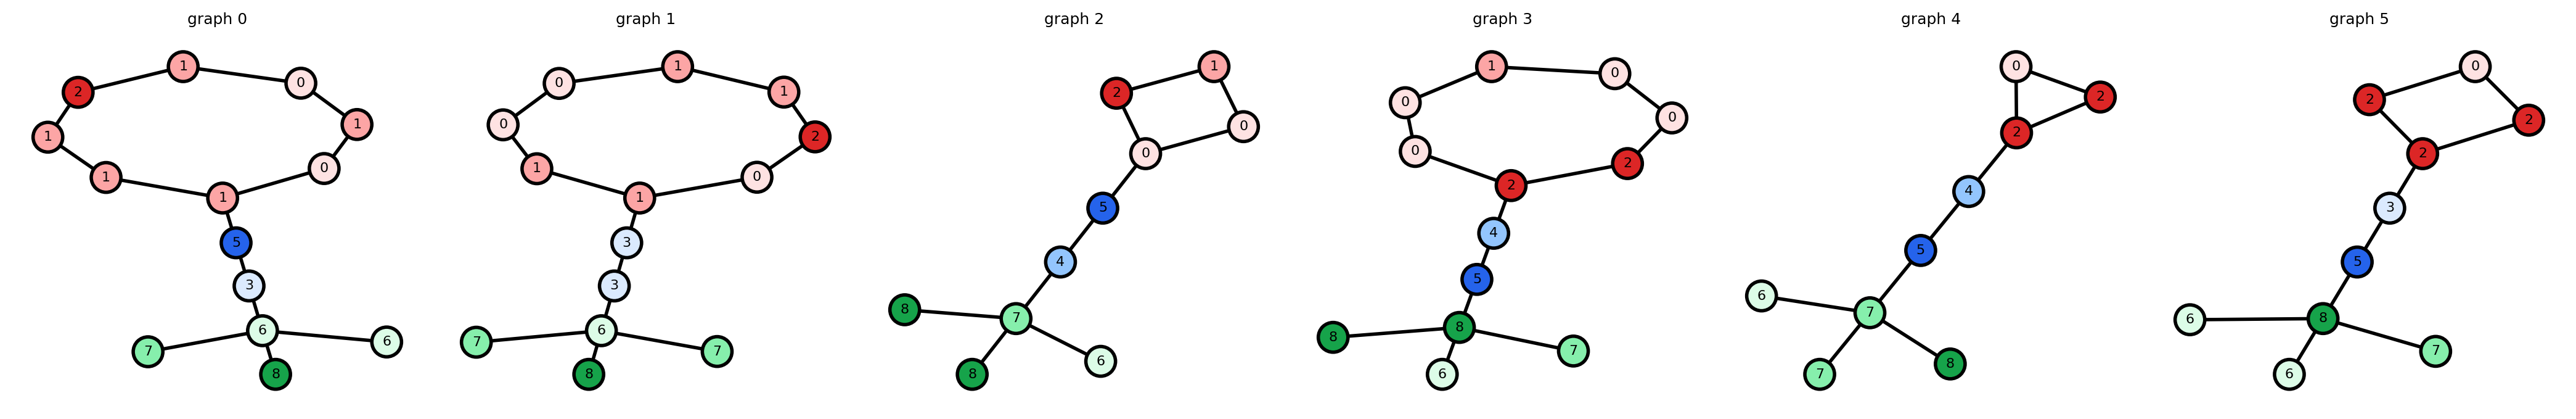

In [3]:
print('Generate the synthetic training graphs and save their configuration for reuse.')
graphs, plot_artificial_graphs = generate_artificial_dataset(
    num_graphs=DATASET_SIZE,
    n_iterations=N_ITERATIONS,
    cycle_length=CYCLE_LENGTH,
    num_cycles=NUM_CYCLES,
    path_length=PATH_LENGTH,
    num_rays=NUM_RAYS,
    ray_length=RAY_LENGTH,
    node_alphabet_size=NODE_ALPHABET_SIZE,
    edge_alphabet_size=EDGE_ALPHABET_SIZE,
    node_alphabet_kind=NODE_ALPHABET_KIND,
    edge_alphabet_kind=EDGE_ALPHABET_KIND,
    component_specific_alphabets=COMPONENT_SPECIFIC_ALPHABETS,
    seed=RANDOM_SEED,
    save_config_dir=REPO_ROOT / 'notebooks' / 'configs' / 'artificial_datasets',
)

node_counts = np.array([graph.number_of_nodes() for graph in graphs])
edge_counts = np.array([graph.number_of_edges() for graph in graphs])
print(f'Loaded {len(graphs)} artificial graphs into memory for non-streaming fit.')
print(f'Node count min/median/max = {node_counts.min()}/{np.median(node_counts):.0f}/{node_counts.max()}')
print(f'Edge count min/median/max = {edge_counts.min()}/{np.median(edge_counts):.0f}/{edge_counts.max()}')
print('Metadata:', graphs[0].graph['metadata'])

num = min(7 * 2, len(graphs))
_ = plot_artificial_graphs(
    graphs[:num],
    n_cols=max(1, min(7, num)),
    titles=[f'graph {idx}' for idx in range(num)],
    size=3.5,
)

Build the generator and prepare the graph display used during training.


In [4]:
print('Build the generator and prepare the graph display used during training.')

# Recurrent energy setup. Set node_field_mode to "baseline" for the original model.
NODE_FIELD_CONFIG = {
    "node_field_mode": "recurrent_energy",
    "recurrent_hidden_dimension": None,  # None uses latent_embedding_dimension.
    "recurrent_training_steps": 8,
    "recurrent_detach_interval": 4,  # None keeps full backpropagation through memory.
    "recurrent_update_scale": 1.0,
    "recurrent_initial_state": "zeros",
    "recurrent_state_normalization": True,
    "recurrent_corruption_schedule": "annealed",  # Also "constant" or "none".
    "recurrent_sigma_min": 0.02,
    "recurrent_sigma_max": None,  # None uses node_field_sigma.
    "recurrent_supervise_all_steps": True,
    "recurrent_loss_discount": 1.0,
}

# Keep new model artifacts distinct from existing baseline checkpoints.
MODEL_NAME = (
    MODEL_NAME.removesuffix("-baseline").removesuffix("-recurrent_energy")
    + "-" + NODE_FIELD_CONFIG["node_field_mode"]
)

graph_generator = build_graph_generator(
    **NODE_FIELD_CONFIG,
    latent_embedding_dimension=EMBEDDING_DIM,
    node_embedding_svd_dimension=EMBEDDING_DIM,
    number_of_transformer_layers=4,
    transformer_attention_head_count=8,
    transformer_dropout=0.0,
    locality_horizon=2,
    sparse_supervision_mask_ratio=0.0,
    cfg_condition_dropout_prob=0.0,
    node_field_sigma=0.05,
    sampling_step_size=0.02,
    sampling_steps=200,
    maximum_epochs=MAXIMUM_EPOCHS,
    batch_size=FIT_BATCH_SIZE,
    enable_early_stopping=False,
    restore_best_checkpoint=False,
    verbose=1,
    decoder_n_jobs=DECODER_N_JOBS,
    artifact_root=ARTIFACT_ROOT,
    checkpoint_root=CHECKPOINT_ROOT,
    model_name=MODEL_NAME,
    model_dir=SAVED_GENERATOR_ROOT,
)
graph_generator.loss_curves_pdf_every_n_epochs = LOSS_CURVES_PDF_EVERY_N_EPOCHS
def render_artificial_graphs(decoded_graphs, **kwargs):
    graph_list = list(decoded_graphs)
    titles = kwargs.get('titles')
    plot_artificial_graphs(
        graph_list,
        n_cols=max(1, min(7, len(graph_list))),
        titles=titles,
    )


graph_generator.graph_decoder.diagnostic_graph_renderer = render_artificial_graphs

TRAINING_PROGRESS_PDF_PATH = ARTIFACT_ROOT / 'samples' / MODEL_NAME / 'training_samples.pdf'
print(f'Training sample PDF: {TRAINING_PROGRESS_PDF_PATH}')

Build the generator and prepare the graph display used during training.
Configured graph generator model_name=artificial-cycle-path-star-n6-c3-8-p2-r3x1-d256-b1-e300-recurrent-energy model_dir=/Users/f.costa/Code/NodeField/.artifacts/saved_generators
Training sample PDF: /Users/f.costa/Code/NodeField/.artifacts/samples/artificial-cycle-path-star-n6-c3-8-p2-r3x1-d256-b1-e300-recurrent_energy/training_samples.pdf


Train the generator on the synthetic graphs. This may take some time.


In [5]:
print('Create a fixed train/holdout split for the overfit generalization test.')
GENERALIZATION_HOLDOUT_FRACTION = 0.50
GENERALIZATION_SPLIT_SEED = 10  # fixed diagnostic split; do not tune per run
split_rng = np.random.default_rng(GENERALIZATION_SPLIT_SEED)
split_indices = split_rng.permutation(len(graphs))
n_holdout = max(1, int(round(GENERALIZATION_HOLDOUT_FRACTION * len(graphs))))
holdout_indices = split_indices[:n_holdout]
fit_indices = split_indices[n_holdout:]
fit_graphs = [graphs[int(index)] for index in fit_indices]
heldout_graphs = [graphs[int(index)] for index in holdout_indices]
print(f'Fit graphs: {len(fit_graphs)} | held-out graphs: {len(heldout_graphs)}')


Create a fixed train/holdout split for the overfit generalization test.
Fit graphs: 3 | held-out graphs: 3


Train the generator on the synthetic graphs. This may take some time.
________________________________________________________________________________
Training target: model 'artificial-cycle-path-star-n6-c3-8-p2-r3x1-d256-b1-e300-recurrent-energy'. Saved model files will go to '/Users/f.costa/Code/NodeField/.artifacts/saved_generators'.
________________________________________________________________________________
Starting training on 3 synthetic graphs. Next, the generator will learn graph representations, prepare its training targets, and train the neural graph generator. This may take some time.
________________________________________________________________________________
Step 1 of 11 | Next: learn how to describe each complete graph with numeric features. Purpose: The generator will use this representation to understand each graph as a whole.
Step 1 of 11 | Done: Learned complete-graph features from 3 graphs. Time: 0m 0.0s.
____________________________________________________

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


Epoch 10/300 | ETA 0h 02m 24s | Next output ETA 0h 00m 05s (10 epochs):
  train total=   1219.2 | node_field    1210.2 [99.3%] |        deg   0.38757 [<0.1%] |      exist   0.48072 [<0.1%] | node_count   0.00635 [<0.1%]
  val   total=   1251.0 | node_field    1227.3 [98.1%] |        deg    2.3226 [0.2%] |      exist   0.09198 [<0.1%] | node_count   0.00050 [<0.1%]
  train                 | node_label   0.55324 [<0.1%] | edge_label   0.21232 [<0.1%] |       edge    1.0502 [<0.1%] | edge_count    5.7888 [0.5%] | deg_edge_consistency   0.00004 [<0.1%]
  val                   | node_label    5.0885 [0.4%] | edge_label    1.2421 [<0.1%] |       edge    1.8468 [0.1%] | edge_count    12.257 [1.0%] | deg_edge_consistency   0.00868 [<0.1%]
  train                 |        aux   0.48838 [<0.1%] | dominant=node_field [99.3%]
  val                   |        aux   0.83267 [<0.1%] | dominant=node_field [98.1%]
epoch 10: sampling training progress graphs
epoch 10: appended training sample PDF page t

`Trainer.fit` stopped: `max_epochs=300` reached.


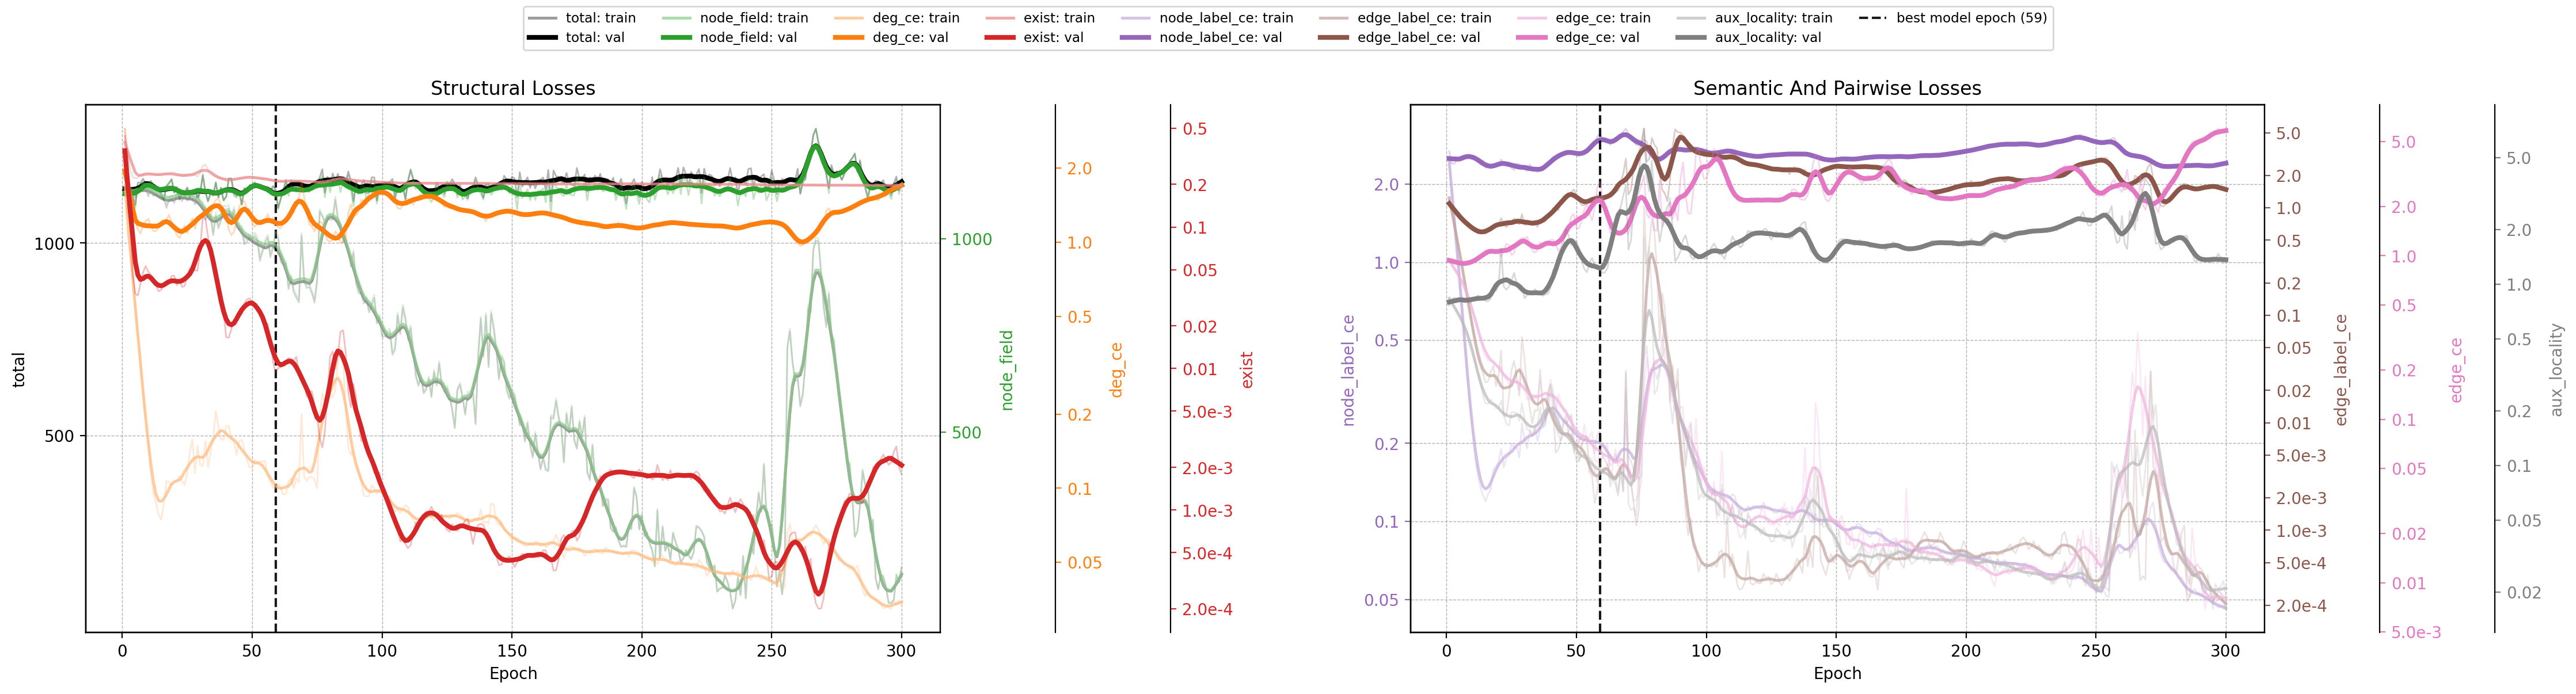

Done: the neural graph generator finished training. Time: 15m 19.8s.
________________________________________________________________________________
Training complete: The generator is ready to create graphs. Total time: 15m 20.9s.
training_graph_conditioning_ = 3
is_fitted_ = True
CPU times: user 9min 47s, sys: 2min 29s, total: 12min 16s
Wall time: 15min 20s


In [6]:
%%time
print('Train the generator on the synthetic graphs. This may take some time.')
if 'fit_graphs' not in globals() or 'heldout_graphs' not in globals():
    GENERALIZATION_HOLDOUT_FRACTION = 0.50
    GENERALIZATION_SPLIT_SEED = 10
    split_rng = np.random.default_rng(GENERALIZATION_SPLIT_SEED)
    split_indices = split_rng.permutation(len(graphs))
    n_holdout = max(1, int(round(GENERALIZATION_HOLDOUT_FRACTION * len(graphs))))
    holdout_indices = split_indices[:n_holdout]
    fit_indices = split_indices[n_holdout:]
    fit_graphs = [graphs[int(index)] for index in fit_indices]
    heldout_graphs = [graphs[int(index)] for index in holdout_indices]
    print(f'Fit graphs: {len(fit_graphs)} | held-out graphs: {len(heldout_graphs)}')
graph_generator.fit(
    fit_graphs,
    sample_training_progress=True,
    sample_training_progress_n_samples=1,
    sample_training_progress_every_n_epochs=10,
    sample_training_progress_pdf_path=TRAINING_PROGRESS_PDF_PATH,
    sample_training_progress_plot_fn=plot_artificial_graphs,
)
print('training_graph_conditioning_ =', len(graph_generator.training_graph_conditioning_))
print('is_fitted_ =', graph_generator.is_fitted_)


Optionally reload a saved generator for later inspection.


In [7]:
print('Optionally reload a saved generator for later inspection.')
# Optional reload path for a previously saved artificial non-streaming model.
from conditional_node_field_graph_generator.persistence import (
    list_saved_graph_generators,
    load_graph_generator,
)

# Keep this false while evaluating the fixed split; an old checkpoint may have
# been trained on all graphs and would invalidate the seen/held-out comparison.
RELOAD_SAVED_GENERATOR = False
if RELOAD_SAVED_GENERATOR:
    list_saved_graph_generators(SAVED_GENERATOR_ROOT)
    MODEL_FILENAME = f'{MODEL_NAME}.pkl'
    graph_generator = load_graph_generator(MODEL_FILENAME, model_dir=SAVED_GENERATOR_ROOT)


Optionally reload a saved generator for later inspection.


Test whether the generator memorizes seen graph conditions but generalizes poorly to held-out graphs. This uses `conditional_sample`, not `sample()`, so it does not draw cached training conditioning rows.


In [8]:
from conditional_node_field_graph_generator.extensions.demo.overfit_evaluation import (
    evaluate_overfit_generalization,
)

GENERALIZATION_SAMPLES_PER_GRAPH = 6
GENERALIZATION_USE_ILP_DECODER = True
overfit_evaluation = evaluate_overfit_generalization(
    graph_generator,
    fit_graphs,
    heldout_graphs,
    samples_per_graph=GENERALIZATION_SAMPLES_PER_GRAPH,
    use_ilp_decoder=GENERALIZATION_USE_ILP_DECODER,
    targets=OVERFIT_TARGETS,
)

train_conditioned = overfit_evaluation['train_conditioned']
heldout_conditioned = overfit_evaluation['heldout_conditioned']
shuffled_fit_conditioned = overfit_evaluation['shuffled_fit_conditioned']
shuffled_heldout_conditioned = overfit_evaluation['shuffled_heldout_conditioned']
train_score = overfit_evaluation['train_score']
heldout_score = overfit_evaluation['heldout_score']
shuffled_fit_score = overfit_evaluation['shuffled_fit_score']
shuffled_heldout_score = overfit_evaluation['shuffled_heldout_score']


Evaluate conditional reconstruction on seen and held-out graphs.
Seen/train conditions: {'exact_rate_per_sample': 0.0, 'exact_rate_any_sample': 0.0, 'node_count_mae': 0.0, 'edge_count_mae': 0.3888888888888889, 'node_label_hist_l1': 0.8984126984126983, 'degree_hist_l1': 0.5984126984126985, 'edge_label_hist_l1': 0.3757335257335257}
Held-out conditions: {'exact_rate_per_sample': 0.0, 'exact_rate_any_sample': 0.0, 'node_count_mae': 0.0, 'edge_count_mae': 0.2777777777777778, 'node_label_hist_l1': 0.9766653099986434, 'degree_hist_l1': 0.27553927553927554, 'edge_label_hist_l1': 0.3183692850359517}
Generalization gap (exact any-sample rate): 0.0
Decoding 18 conditioning vectors
Decoding 18 conditioning vectors
Shuffled seen/train conditions: {'exact_rate_per_sample': 0.0, 'exact_rate_any_sample': 0.0, 'node_count_mae': 0.0, 'edge_count_mae': 0.5555555555555556, 'node_label_hist_l1': 0.9095238095238096, 'degree_hist_l1': 0.3396825396825397, 'edge_label_hist_l1': 0.3866522366522366}
Shuffled hel

Visualize reference graphs beside seen, held-out, and mismatched-condition reconstructions.


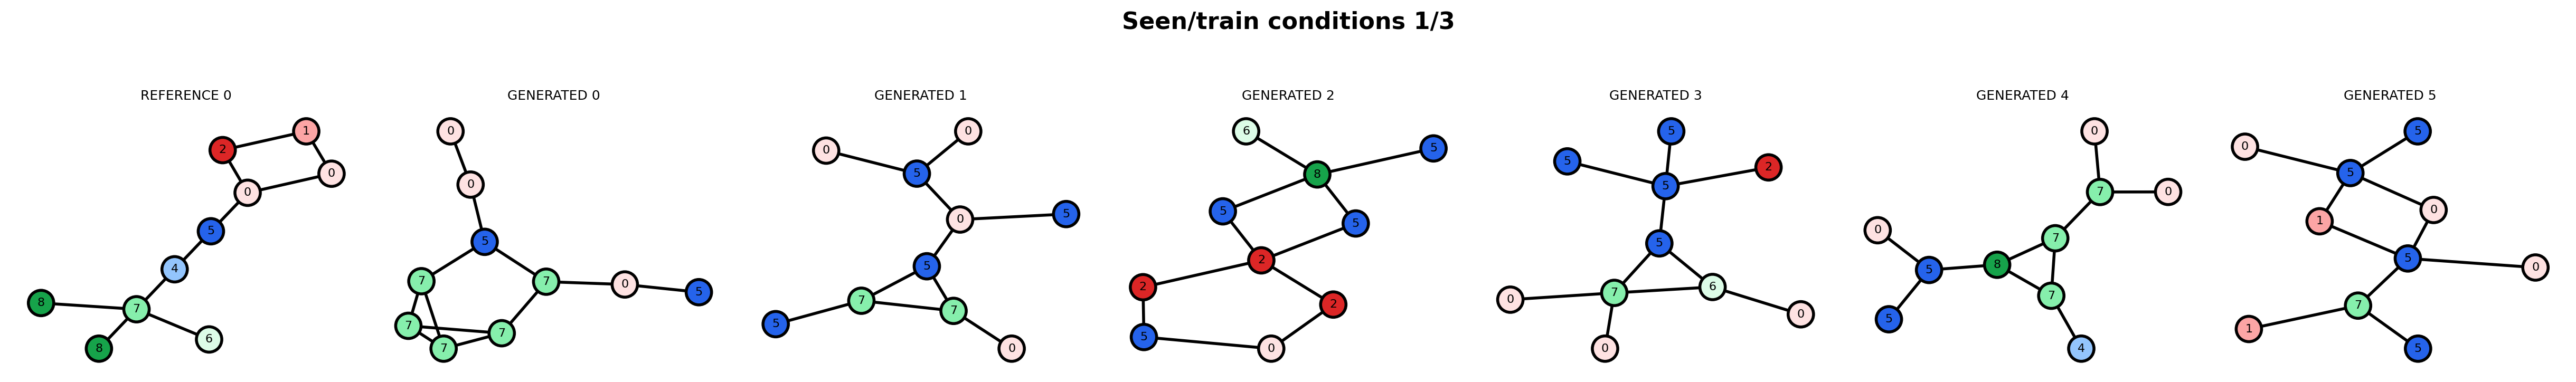

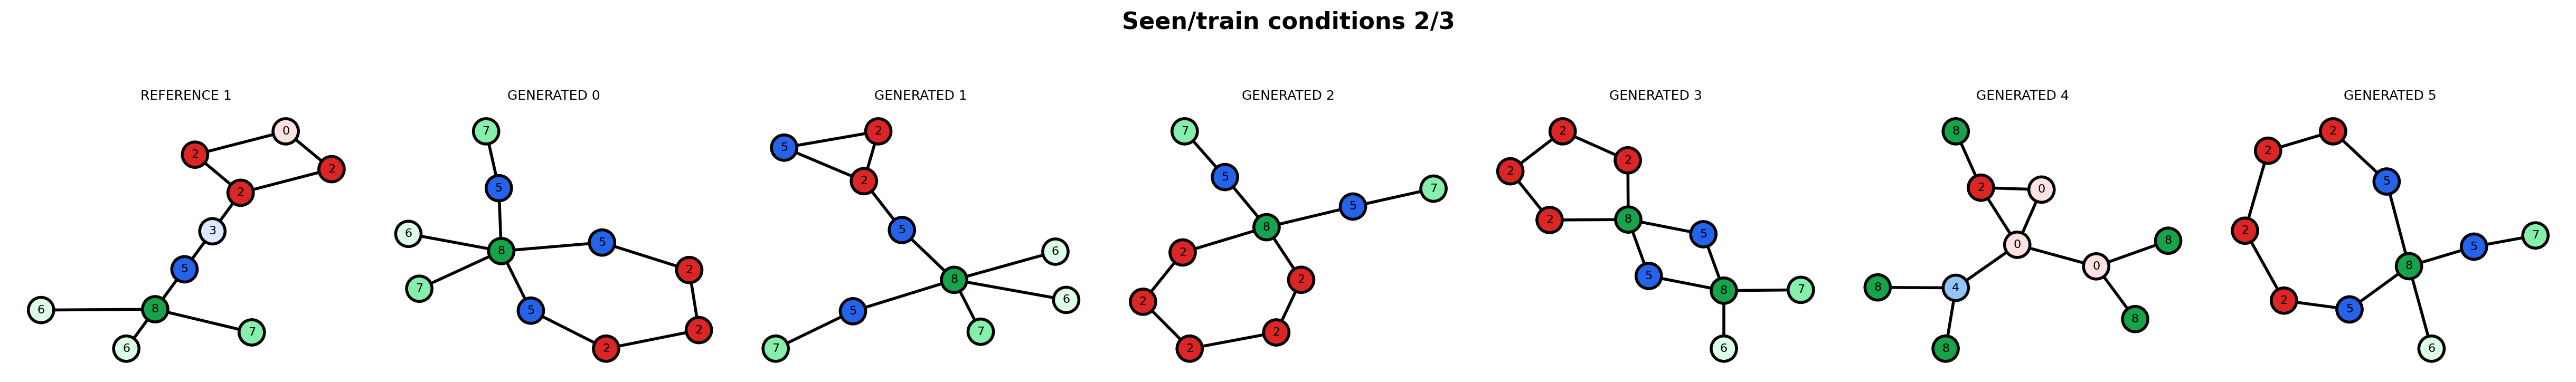

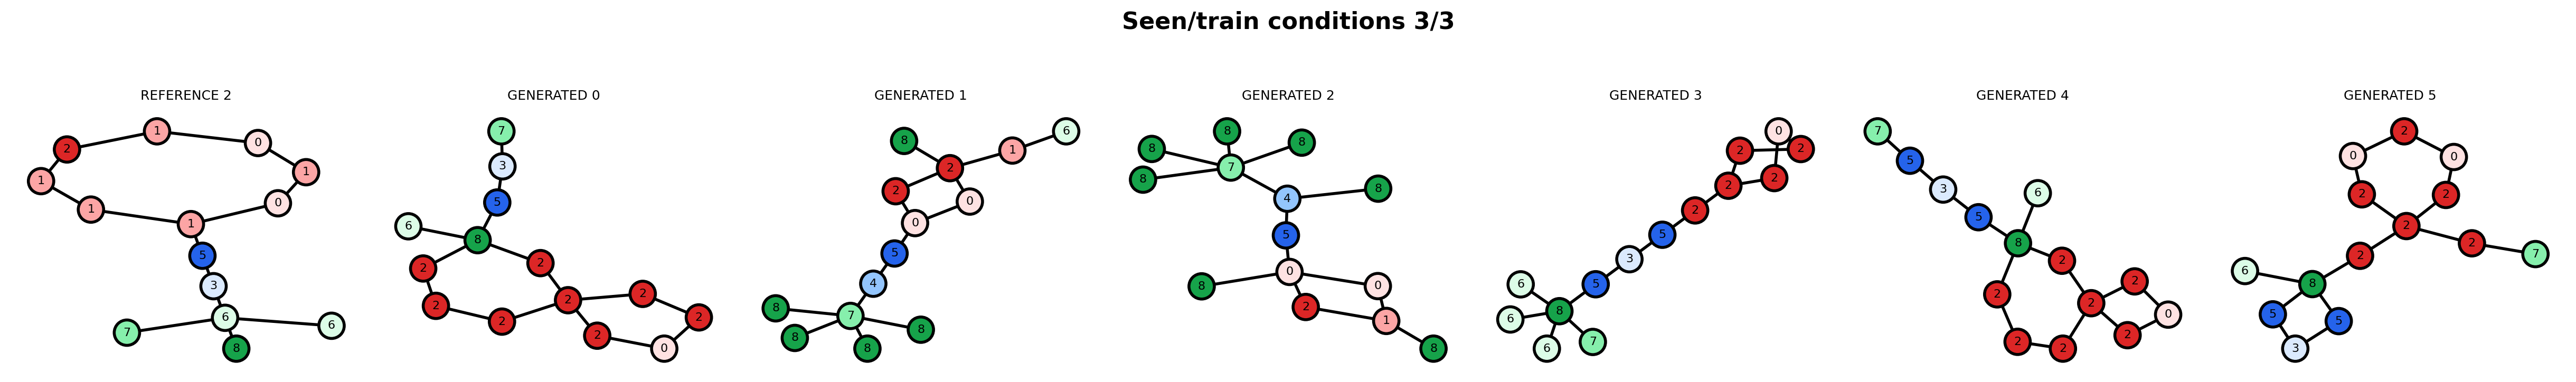

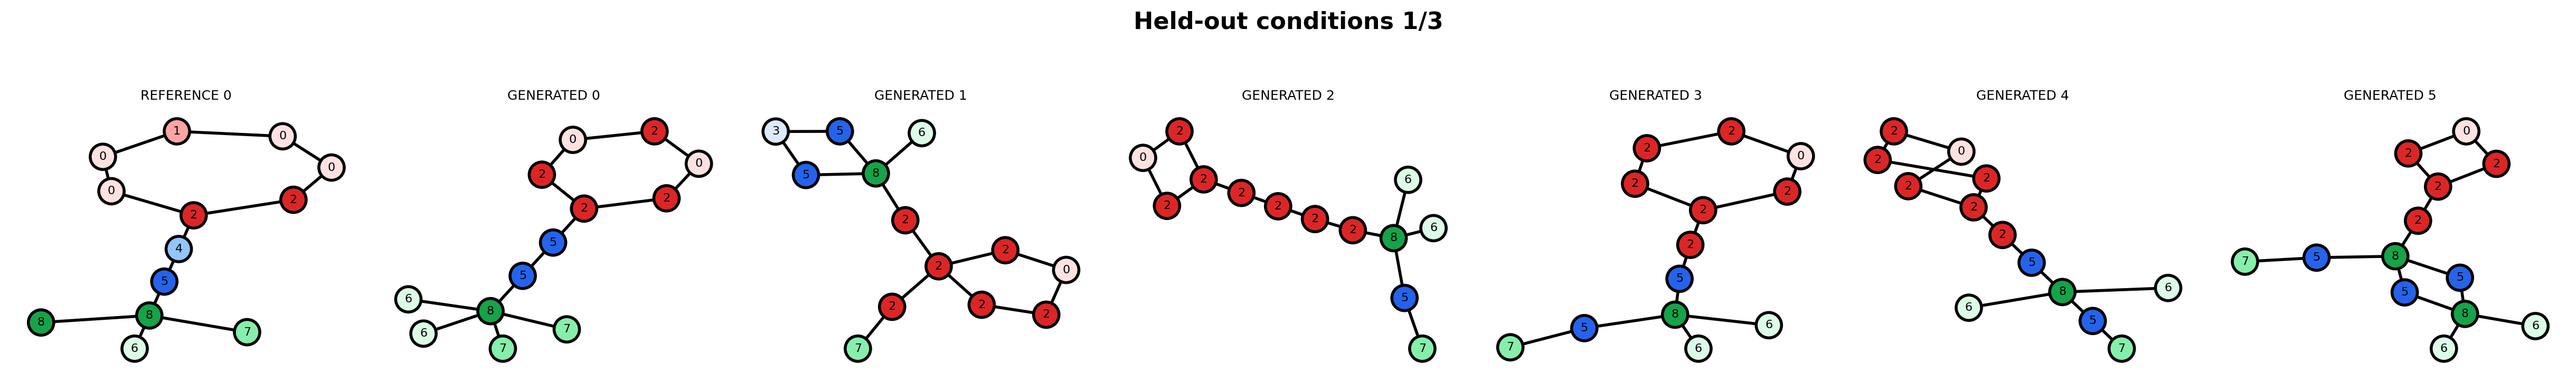

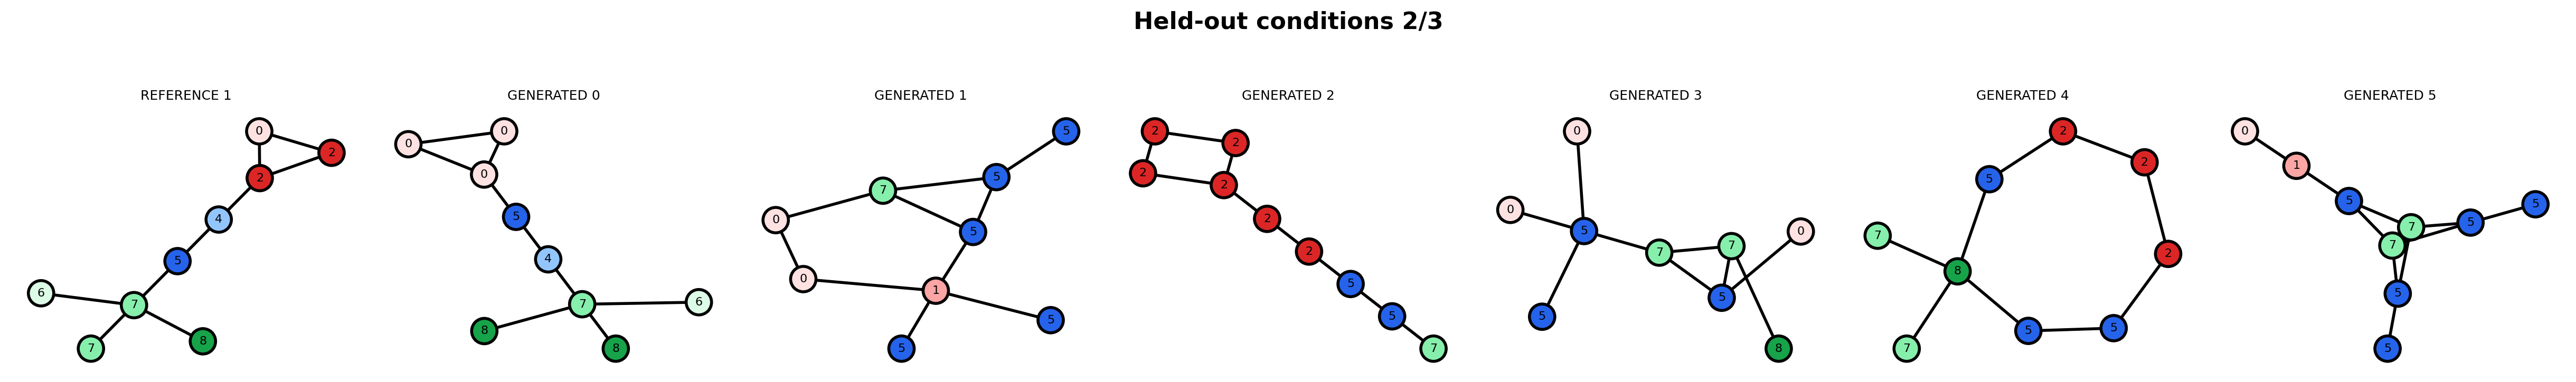

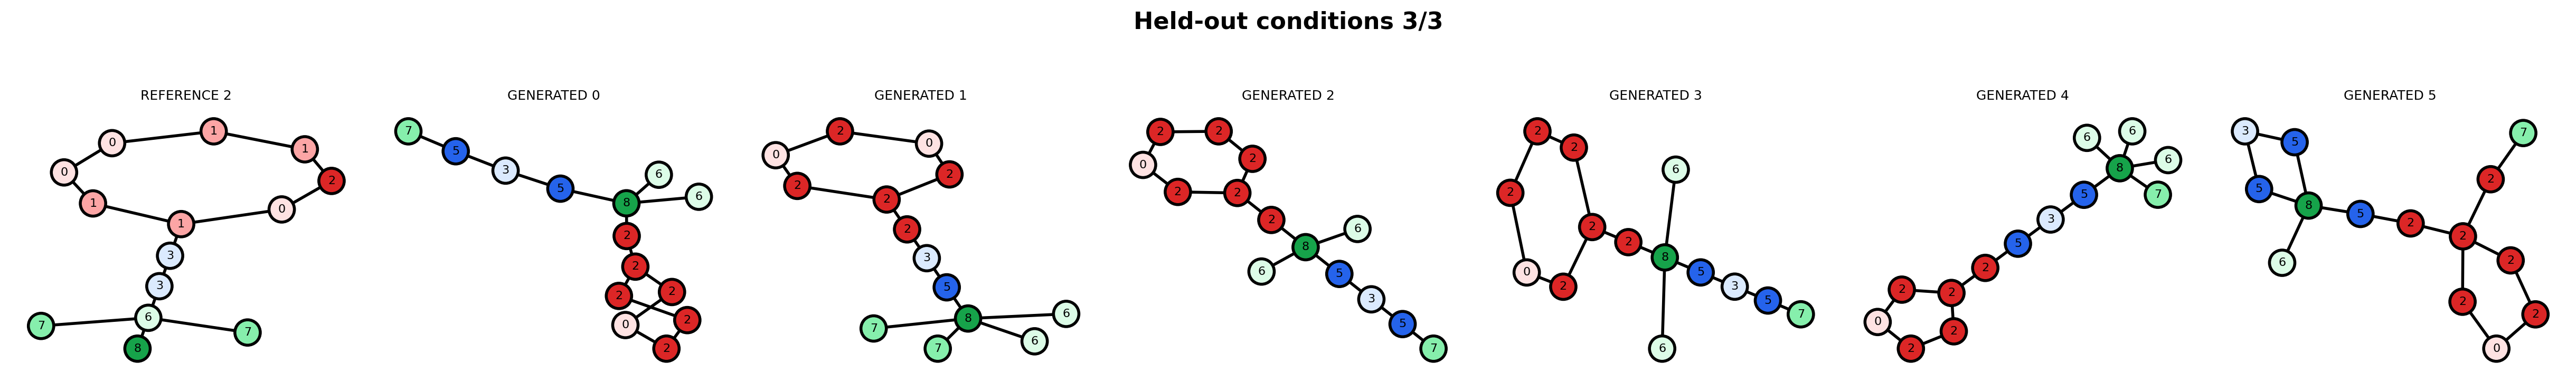

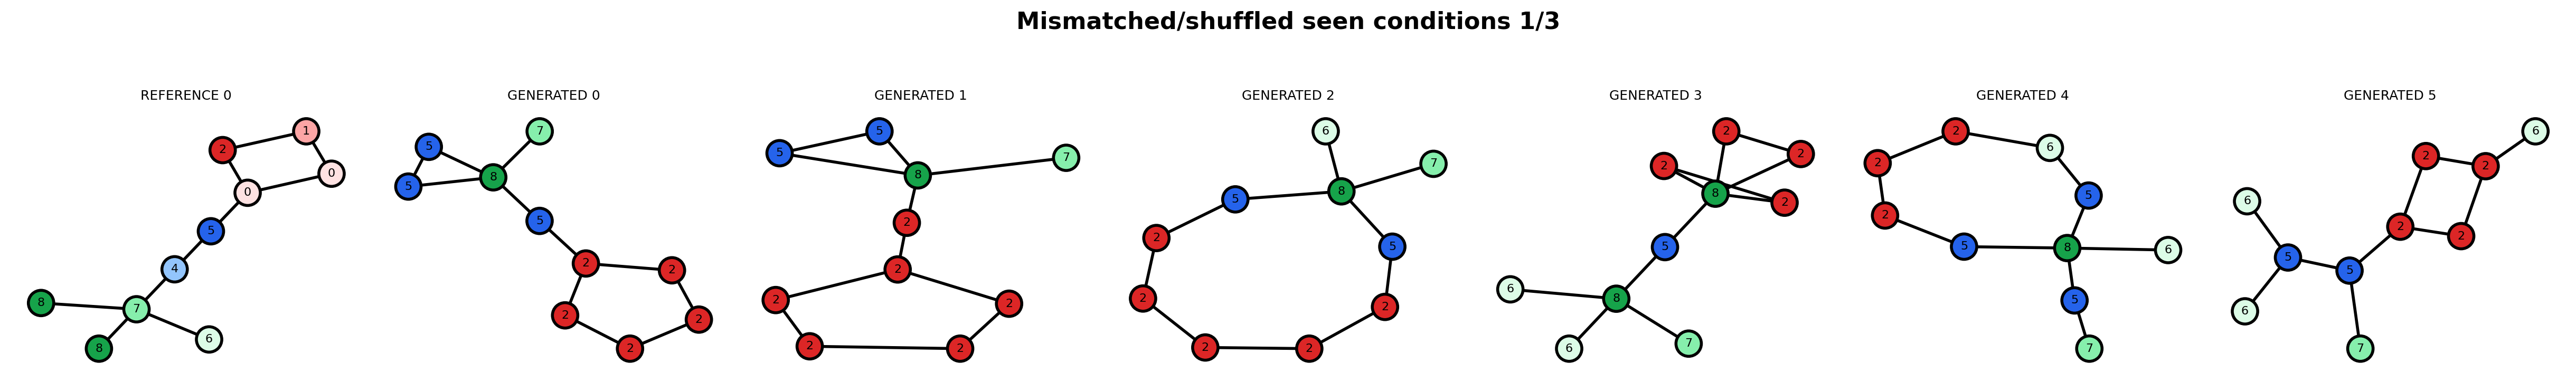

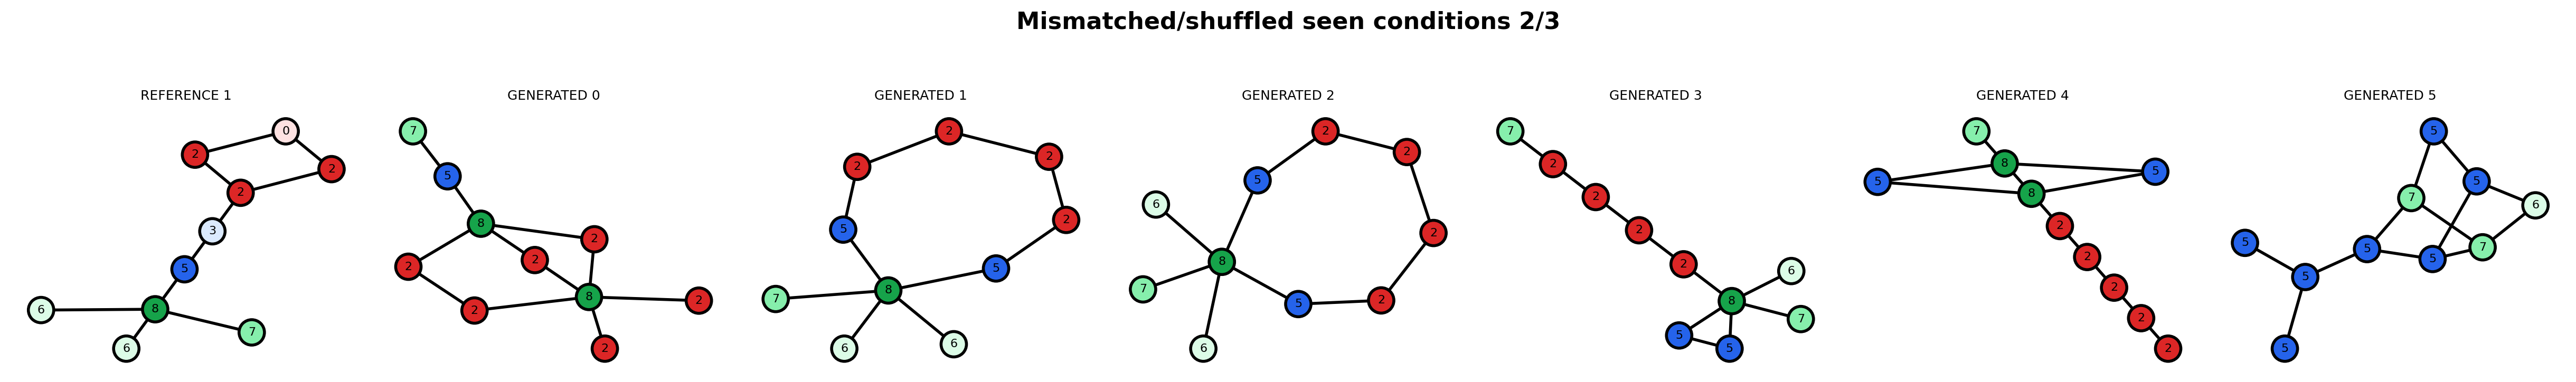

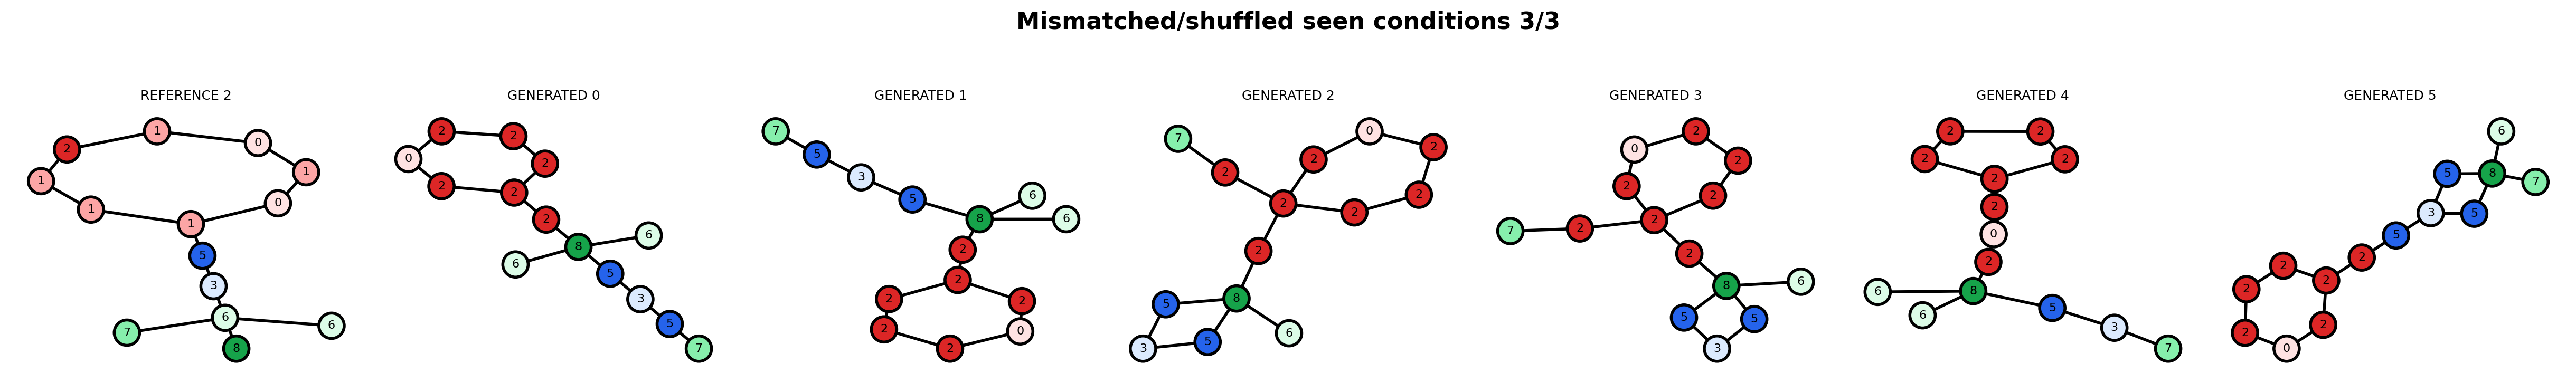

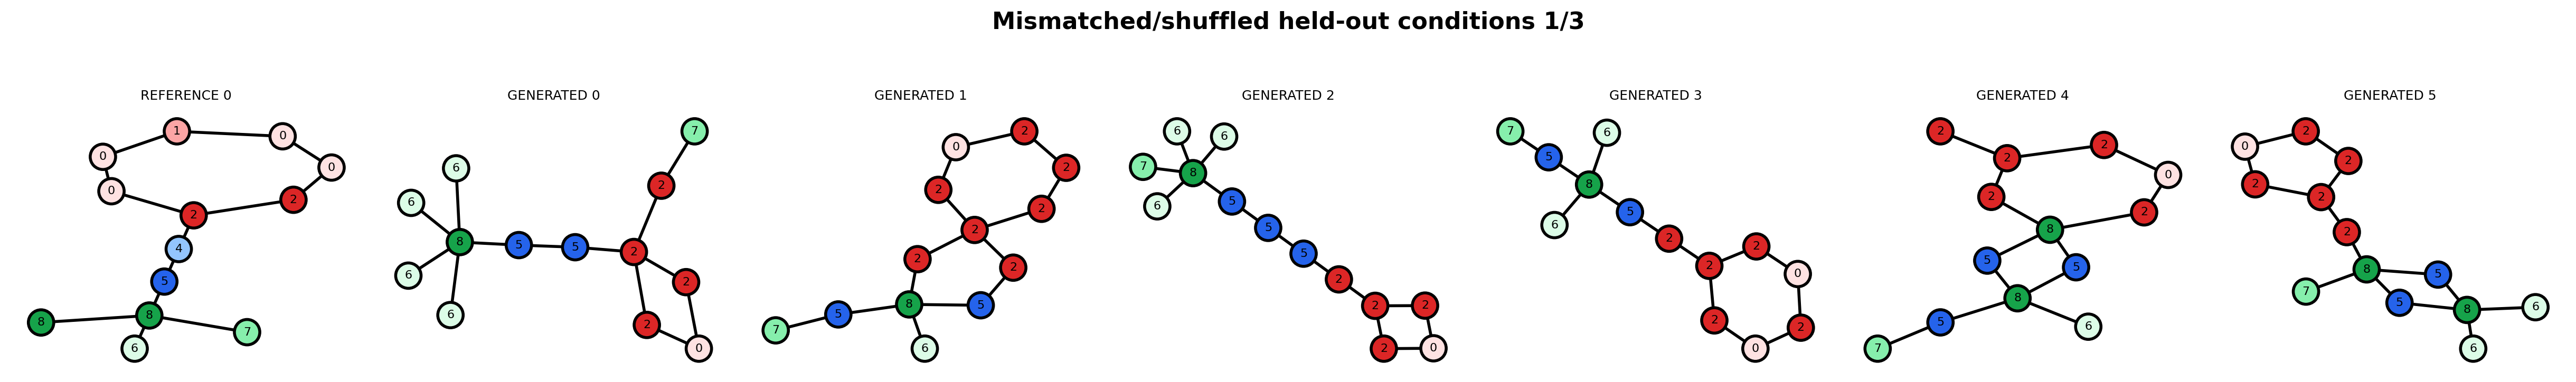

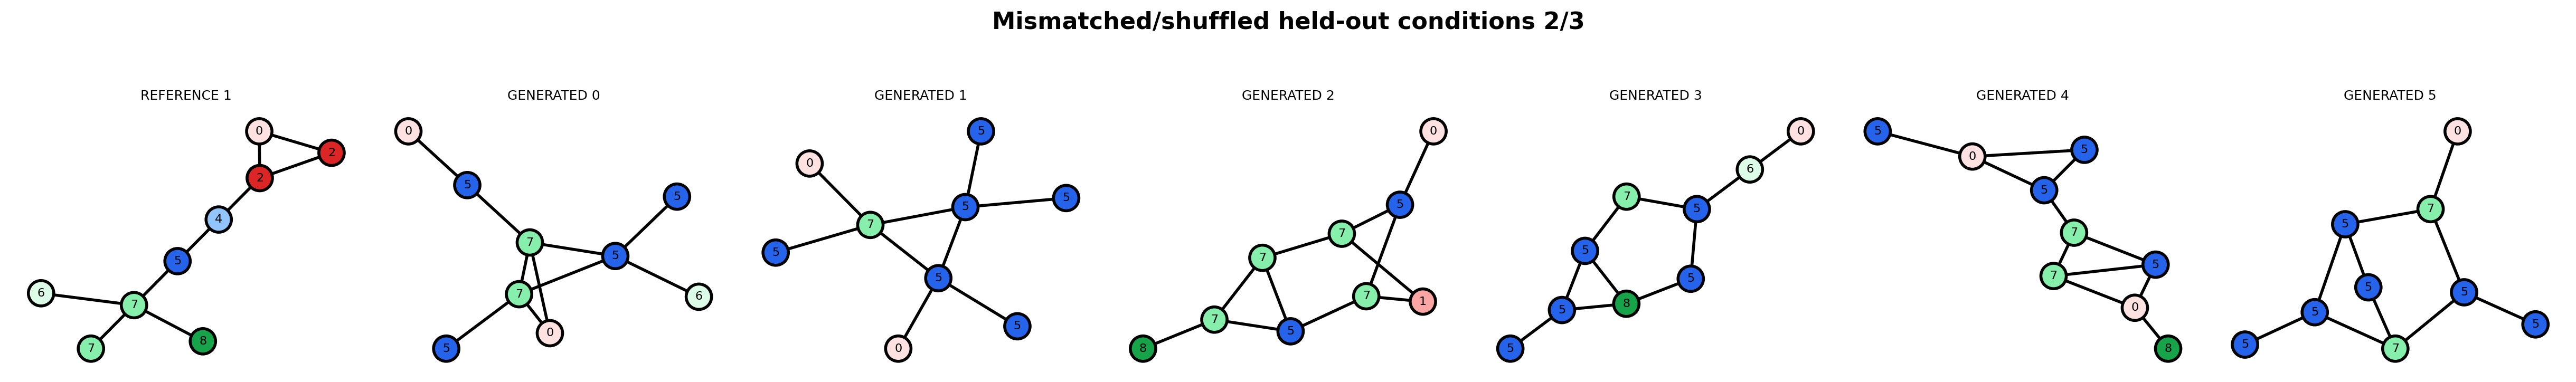

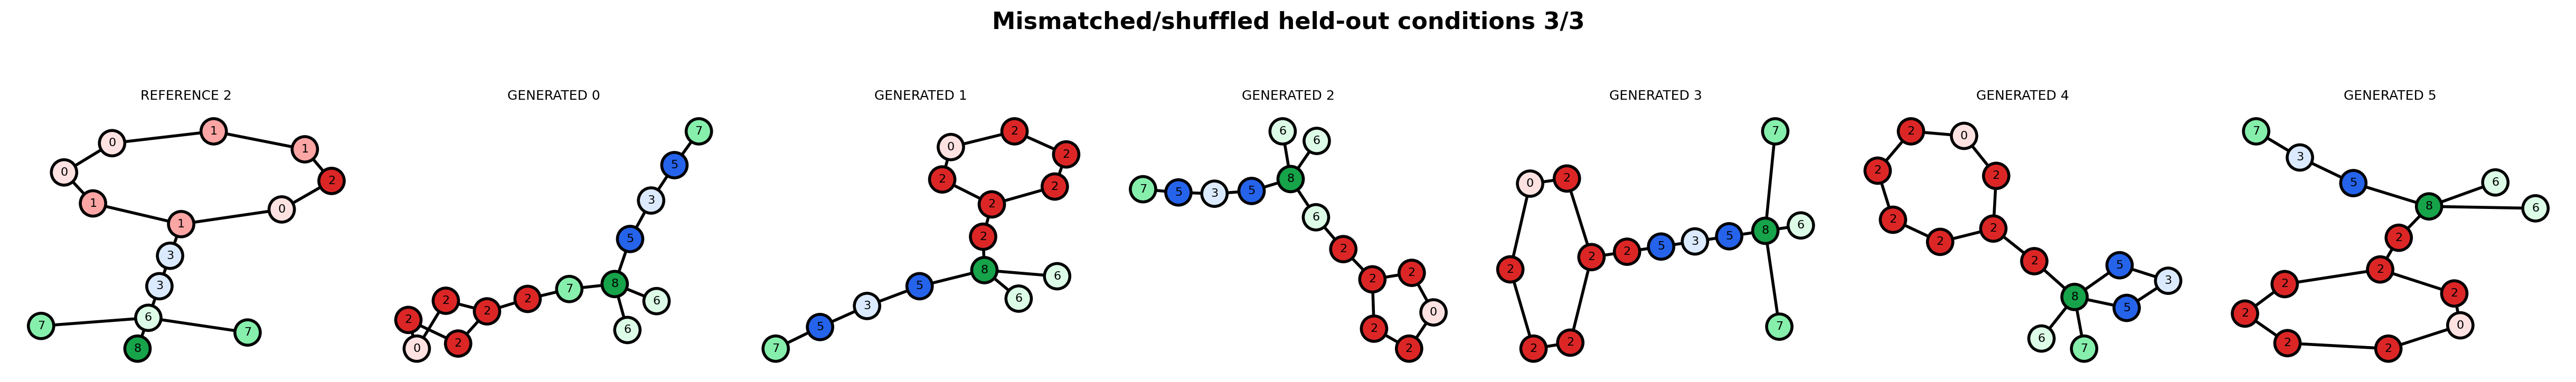

In [9]:
from conditional_node_field_graph_generator.extensions.demo.overfit_evaluation import (
    plot_overfit_reconstructions,
)

plot_overfit_reconstructions(
    plot_artificial_graphs,
    overfit_evaluation,
    fit_graphs,
    heldout_graphs,
    n_candidates=6,
)


Generate samples and display the results with feasibility filtering.


Generate samples and display the results with feasibility filtering.


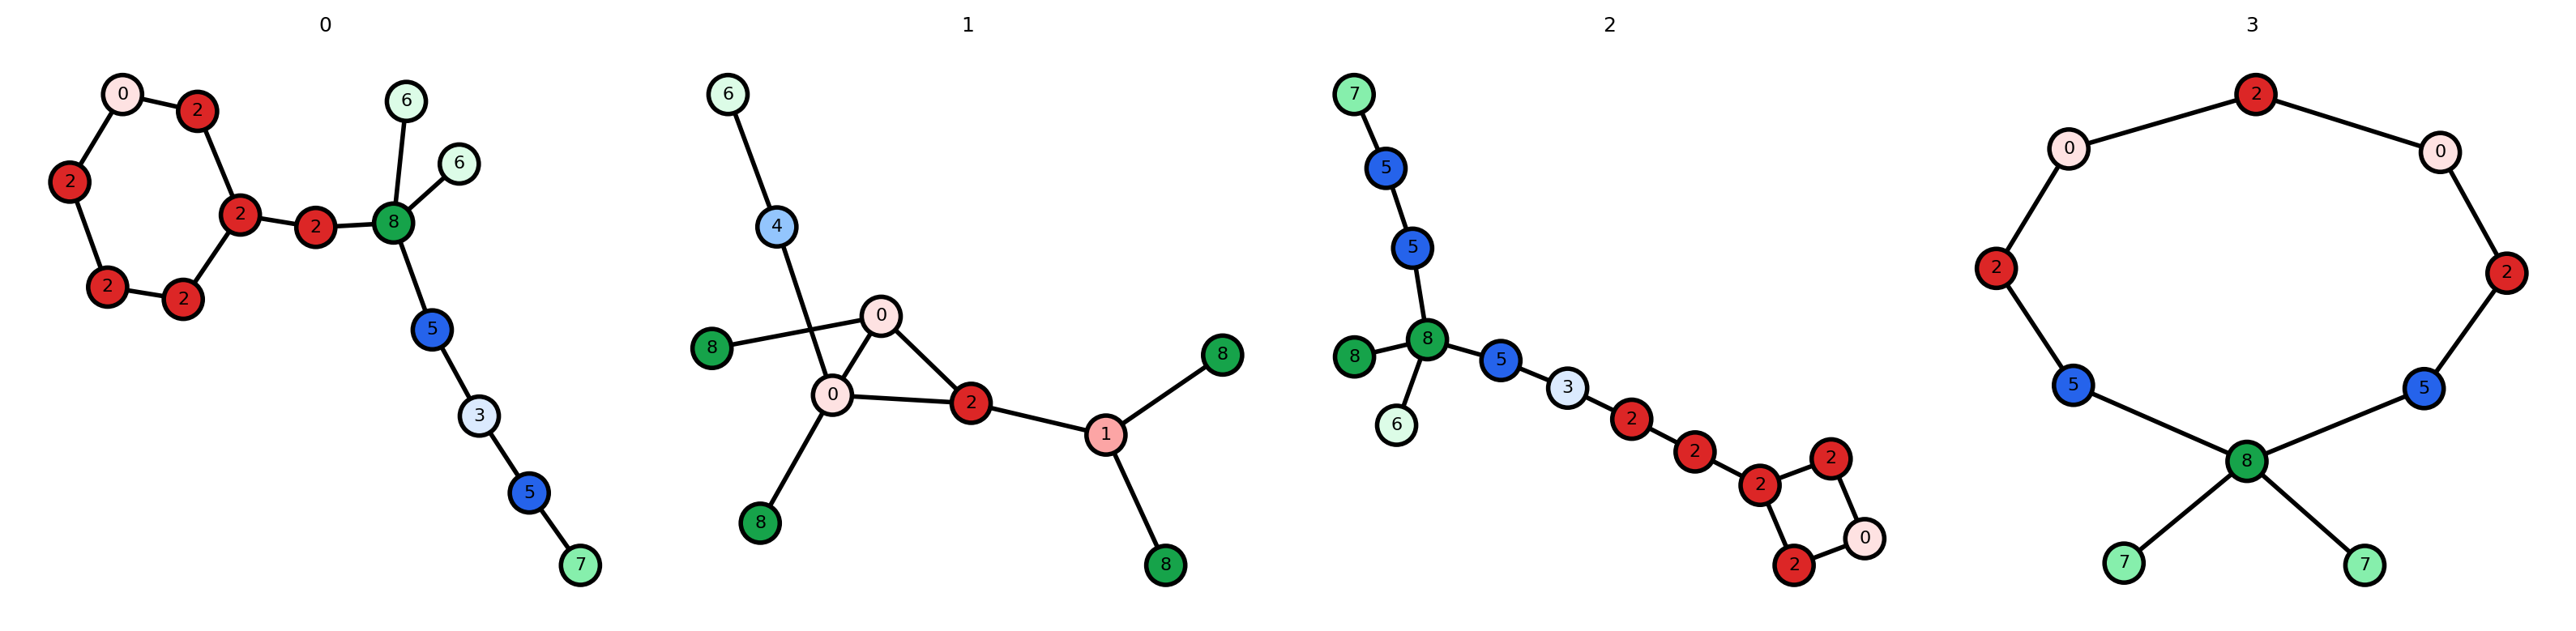

In [10]:
print('Generate samples and display the results with feasibility filtering.')
N_SAMPLES = 4
FEASIBILITY_EFFORT = 1
FEASIBILITY_FILTER = 'none' # 'none', 'fallback', or 'strict'
filtered_samples = graph_generator.sample(
    n_samples=N_SAMPLES,
    feasibility_effort=FEASIBILITY_EFFORT,
    feasibility_filter=FEASIBILITY_FILTER,
)
_ = plot_artificial_graphs(
    filtered_samples,
    n_cols=N_SAMPLES,
    titles=[f'{idx}' for idx in range(len(filtered_samples))],
)

Compare the graphs produced at each decoding stage.


Compare the graphs produced at each decoding stage.


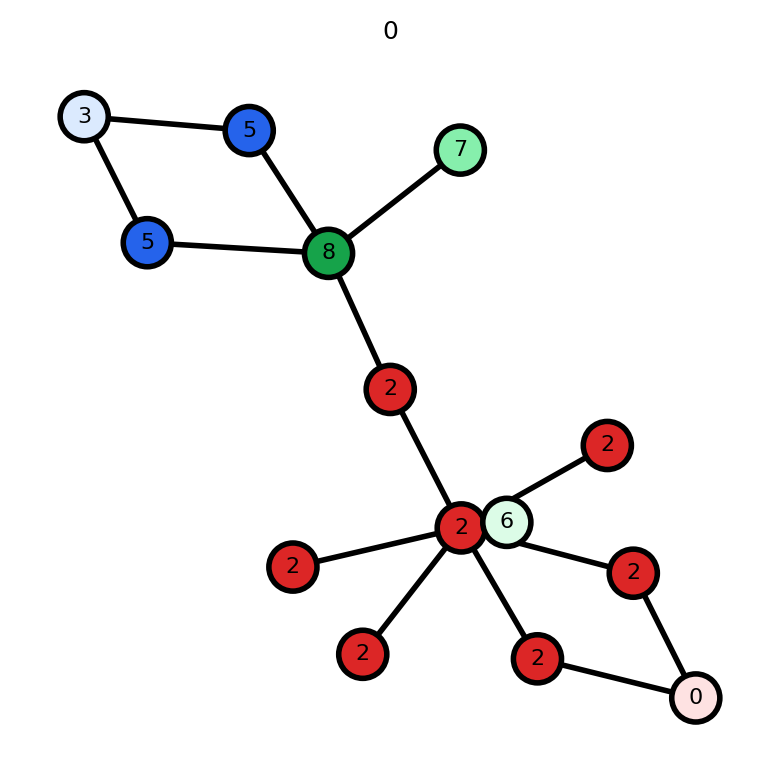

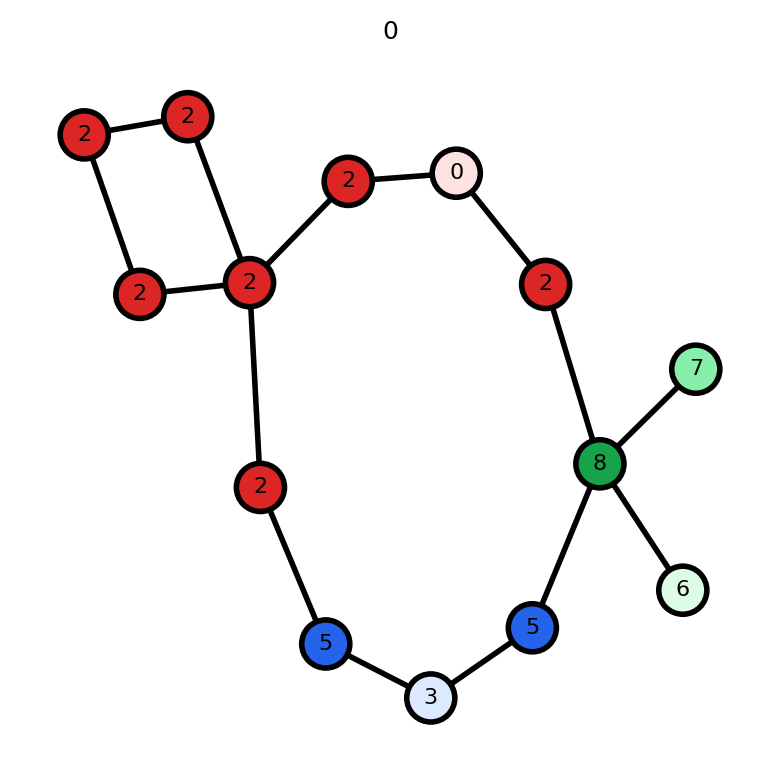

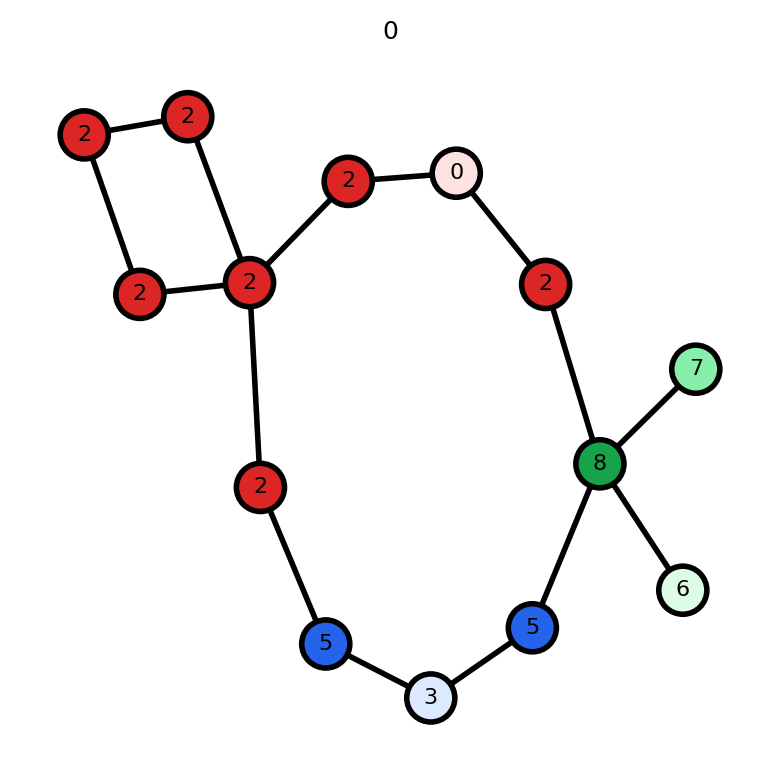

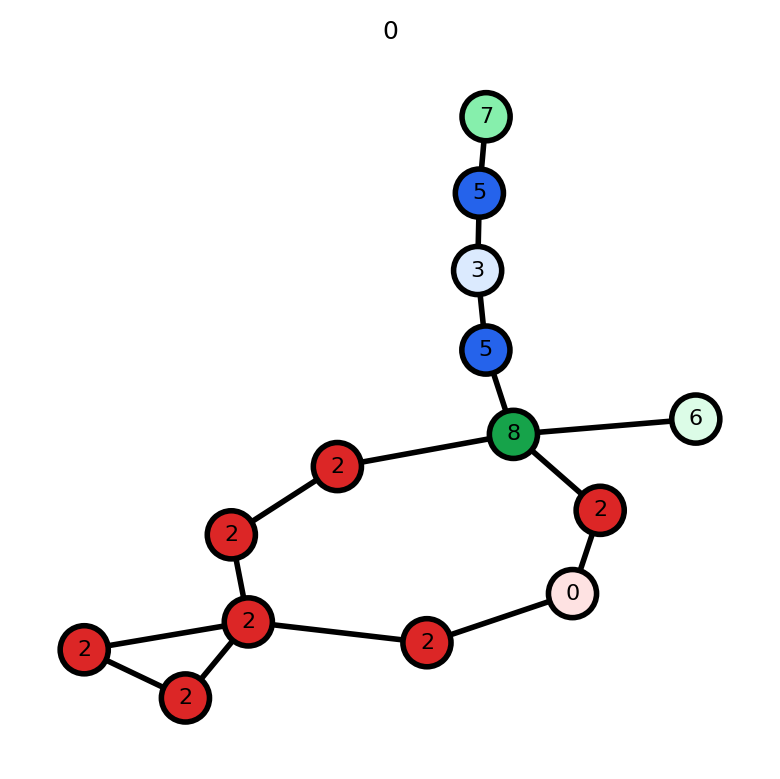

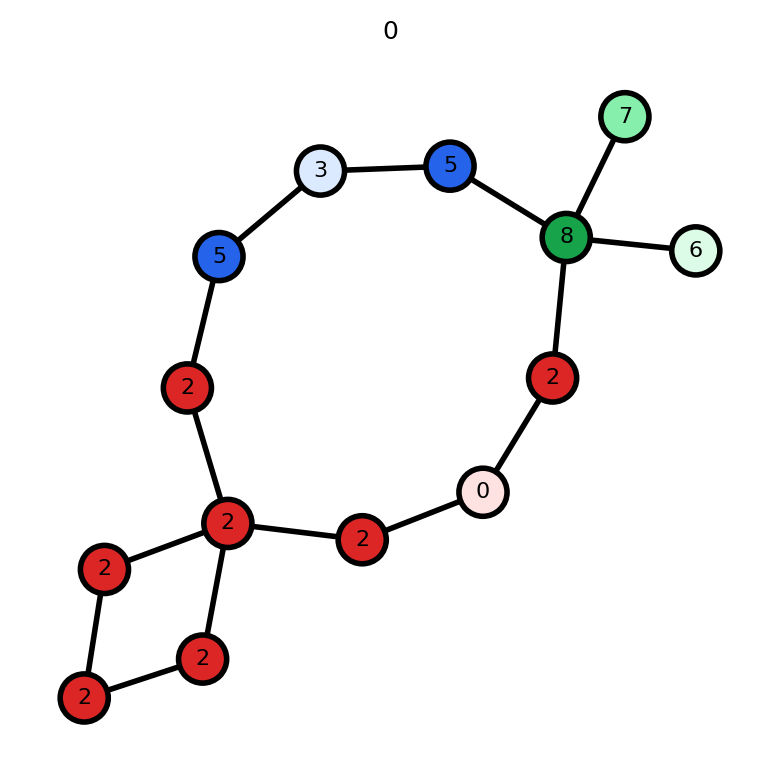

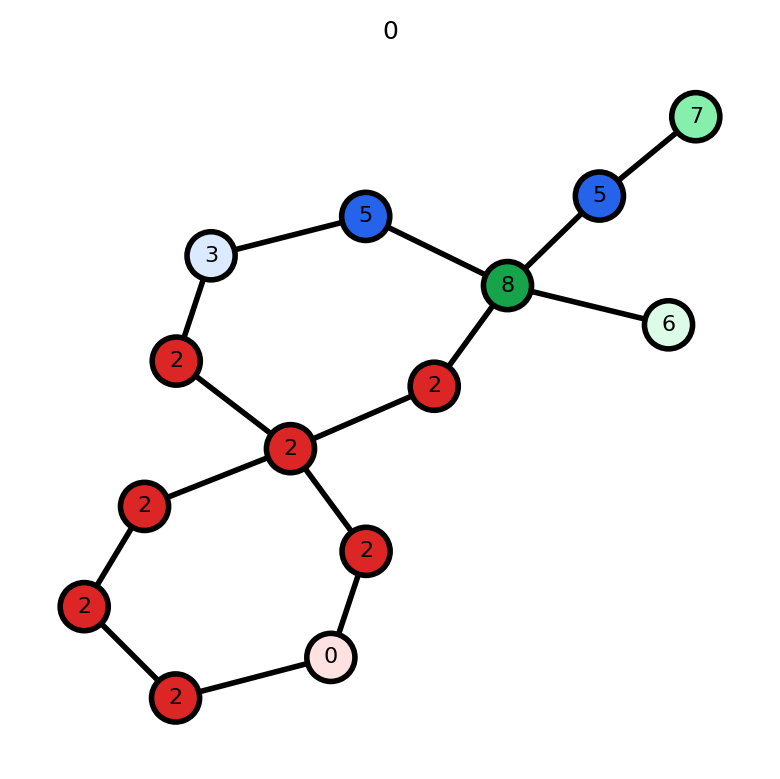

In [11]:
print('Compare the graphs produced at each decoding stage.')
n_samples = 1
sample_variants = graph_generator.sample(n_samples, return_decode_stages=True)

for variant_key in sample_variants:
    variant_samples = sample_variants[variant_key]
    plot_artificial_graphs(
        variant_samples,
        n_cols=n_samples,
        titles=[f'{idx}' for idx in range(len(variant_samples))],
    )